# Cyclistic: Understanding Rider Usage for Sustainable Long Term Growth
By Anis Ahmed

## Background: Understanding Cyclistic's Business Model

Since its inception in 2016, Cyclistic's popularity and usefulness amongst users has led to incredulous growth. Cyclistic has grown to a fleet of 5,824 bicycles that are geotracked and locked into a network of 692 stations across Chicago. The bikes can be unlocked from one station and returned to any other station in the system anytime.

Given this business model Cyclistic’s marketing strategy relies on building general awareness and appealing to broad consumer segments. One approach that helped make these things possible was the flexibility of its pricing plans: single-ride passes, full-day passes, and annual memberships. Customers who purchase single-ride or full-day passes are referred to as **casual riders**. Customers who purchase annual memberships are Cyclistic **members**. In terms of financial viability, the finance analysts at Cyclistic have concluded that **memberships** are more profitable than **casual riders** due to the nature of their uses.

## Defining the Business Task

Given the two customer classes, **casual riders** and **members**, the marketing director has come up with a hypothesis: converting **casual riders** into **members** would lead to better growth prospects for Cyclistic. This study will aim to back this hypothesis up by answering the following questions:

  1. How do annual members and casual riders use Cyclistic bikes differently?
  2. Why would casual riders buy Cyclistic annual memberships?
  3. How can Cyclistic use digital media to influence casual riders to become members?

#### The Stakeholders

The stakeholders for the purpose of this study are:

  1. **Lily Moreno**: The director of marketing. Responsible for the development of campaigns and initiatives   to promote the bike-share program. These may include email, social media, and other channels.
  2. **Cyclistic marketing analytics team**: A team of data analysts who are responsible for collecting, analyzing, and reporting data that helps guide Cyclistic marketing strategy.
  3. **Cyclistic executive team**: Responsible for undertaking executive decisions.
  
## The Data

The data for this study is Cyclistic's own historical trip data. We will use trip data from April 2020 to April 2021. One point to note is that data-privacy issues prohibit us from using riders’ personally identifiable information. This means that we won’t be able to connect pass purchases to credit card numbers to determine if casual riders live in the Cyclistic service area or if they have purchased multiple single passes.

The data has been made available by Motivate International Inc. under this [license](https://www.divvybikes.com/data-license-agreement).

#### Installing the Relevant Packages

In [1]:
library(tidyverse)
library(readr)
library(dplyr)
library(lubridate)
library(magrittr)

── Attaching packages ─────────────────────────────────────── tidyverse 1.3.1 ──

✔ ggplot2 3.3.5     ✔ purrr   0.3.4
✔ tibble  3.1.5     ✔ dplyr   1.0.7
✔ tidyr   1.1.4     ✔ stringr 1.4.0
✔ readr   2.0.2     ✔ forcats 0.5.1

── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()


Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union



Attaching package: ‘magrittr’


The following object is masked from ‘package:purrr’:

    set_names


The following object is masked from ‘package:tidyr’:

    extract




#### Loading the Datasets and Binding Them Vertically

In [2]:
## First we will load the data sets using read.csv()
data_202004 <- read.csv("../input/cyclistic-bike-share/202004-divvy-tripdata.csv")
data_202005 <- read.csv("../input/cyclistic-bike-share/202005-divvy-tripdata.csv")
data_202006 <- read.csv("../input/cyclistic-bike-share/202006-divvy-tripdata.csv")
data_202007 <- read.csv("../input/cyclistic-bike-share/202007-divvy-tripdata.csv")
data_202008 <- read.csv("../input/cyclistic-bike-share/202008-divvy-tripdata.csv")
data_202009 <- read.csv("../input/cyclistic-bike-share/202009-divvy-tripdata.csv")
data_202010 <- read.csv("../input/cyclistic-bike-share/202010-divvy-tripdata.csv")
data_202011 <- read.csv("../input/cyclistic-bike-share/202011-divvy-tripdata.csv")
data_202012 <- read.csv("../input/cyclistic-bike-share/202012-divvy-tripdata.csv")
data_202101 <- read.csv("../input/cyclistic-bike-share/202101-divvy-tripdata.csv")
data_202102 <- read.csv("../input/cyclistic-bike-share/202102-divvy-tripdata.csv")
data_202103 <- read.csv("../input/cyclistic-bike-share/202103-divvy-tripdata.csv")
data_202104 <- read.csv("../input/cyclistic-bike-share/202104-divvy-tripdata.csv")

## Using colnames() we will make sure the column names of the datasets are consistent
colnames(data_202004)
colnames(data_202005)
colnames(data_202006)
colnames(data_202007)
colnames(data_202008)
colnames(data_202009)
colnames(data_202010)
colnames(data_202011)
colnames(data_202012)
colnames(data_202101)
colnames(data_202102)
colnames(data_202103)
colnames(data_202104)

[1] "ride_id"            "rideable_type"      "started_at"        
 [4] "ended_at"           "start_station_name" "start_station_id"  
 [7] "end_station_name"   "end_station_id"     "start_lat"         
[10] "start_lng"          "end_lat"            "end_lng"           
[13] "member_casual"

[1] "ride_id"            "rideable_type"      "started_at"        
 [4] "ended_at"           "start_station_name" "start_station_id"  
 [7] "end_station_name"   "end_station_id"     "start_lat"         
[10] "start_lng"          "end_lat"            "end_lng"           
[13] "member_casual"

[1] "ride_id"            "rideable_type"      "started_at"        
 [4] "ended_at"           "start_station_name" "start_station_id"  
 [7] "end_station_name"   "end_station_id"     "start_lat"         
[10] "start_lng"          "end_lat"            "end_lng"           
[13] "member_casual"

[1] "ride_id"            "rideable_type"      "started_at"        
 [4] "ended_at"           "start_station_name" "start_station_id"  
 [7] "end_station_name"   "end_station_id"     "start_lat"         
[10] "start_lng"          "end_lat"            "end_lng"           
[13] "member_casual"

[1] "ride_id"            "rideable_type"      "started_at"        
 [4] "ended_at"           "start_station_name" "start_station_id"  
 [7] "end_station_name"   "end_station_id"     "start_lat"         
[10] "start_lng"          "end_lat"            "end_lng"           
[13] "member_casual"

...

[1] "ride_id"            "rideable_type"      "started_at"        
 [4] "ended_at"           "start_station_name" "start_station_id"  
 [7] "end_station_name"   "end_station_id"     "start_lat"         
[10] "start_lng"          "end_lat"            "end_lng"           
[13] "member_casual"

[1] "ride_id"            "rideable_type"      "started_at"        
 [4] "ended_at"           "start_station_name" "start_station_id"  
 [7] "end_station_name"   "end_station_id"     "start_lat"         
[10] "start_lng"          "end_lat"            "end_lng"           
[13] "member_casual"

[1] "ride_id"            "rideable_type"      "started_at"        
 [4] "ended_at"           "start_station_name" "start_station_id"  
 [7] "end_station_name"   "end_station_id"     "start_lat"         
[10] "start_lng"          "end_lat"            "end_lng"           
[13] "member_casual"

[1] "ride_id"            "rideable_type"      "started_at"        
 [4] "ended_at"           "start_station_name" "start_station_id"  
 [7] "end_station_name"   "end_station_id"     "start_lat"         
[10] "start_lng"          "end_lat"            "end_lng"           
[13] "member_casual"

[1] "ride_id"            "rideable_type"      "started_at"        
 [4] "ended_at"           "start_station_name" "start_station_id"  
 [7] "end_station_name"   "end_station_id"     "start_lat"         
[10] "start_lng"          "end_lat"            "end_lng"           
[13] "member_casual"

Column names are confirmed to be consistent. We can now go ahead and combine the datasets vertically.

In [3]:
## We combine the datasets vertically using rbind()
total_data_v1 <- rbind(data_202004, data_202005, data_202006, data_202007, data_202008, data_202009, data_202010, data_202011, data_202012, data_202101, data_202102, data_202103, data_202104)
head(total_data_v1)

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,A847FADBBC638E45,docked_bike,2020-04-26 17:45:14,2020-04-26 18:12:03,Eckhart Park,86,Lincoln Ave & Diversey Pkwy,152,41.8964,-87.6610,41.9322,-87.6586,member
2,5405B80E996FF60D,docked_bike,2020-04-17 17:08:54,2020-04-17 17:17:03,Drake Ave & Fullerton Ave,503,Kosciuszko Park,499,41.9244,-87.7154,41.9306,-87.7238,member
3,5DD24A79A4E006F4,docked_bike,2020-04-01 17:54:13,2020-04-01 18:08:36,McClurg Ct & Erie St,142,Indiana Ave & Roosevelt Rd,255,41.8945,-87.6179,41.8679,-87.6230,member
4,2A59BBDF5CDBA725,docked_bike,2020-04-07 12:50:19,2020-04-07 13:02:31,California Ave & Division St,216,Wood St & Augusta Blvd,657,41.9030,-87.6975,41.8992,-87.6722,member
5,27AD306C119C6158,docked_bike,2020-04-18 10:22:59,2020-04-18 11:15:54,Rush St & Hubbard St,125,Sheridan Rd & Lawrence Ave,323,41.8902,-87.6262,41.9695,-87.6547,casual
6,356216E875132F61,docked_bike,2020-04-30 17:55:47,2020-04-30 18:01:11,Mies van der Rohe Way & Chicago Ave,173,Streeter Dr & Grand Ave,35,41.8969,-87.6217,41.8923,-87.6120,member


#### Cleaning the Dataset

##### Fixing Column Types

Let's run the str() function to check column datatypes.str(total_data_v1)

In [4]:
str(total_data_v1)

'data.frame':	3826978 obs. of  13 variables:
 $ ride_id           : chr  "A847FADBBC638E45" "5405B80E996FF60D" "5DD24A79A4E006F4" "2A59BBDF5CDBA725" ...
 $ rideable_type     : chr  "docked_bike" "docked_bike" "docked_bike" "docked_bike" ...
 $ started_at        : chr  "2020-04-26 17:45:14" "2020-04-17 17:08:54" "2020-04-01 17:54:13" "2020-04-07 12:50:19" ...
 $ ended_at          : chr  "2020-04-26 18:12:03" "2020-04-17 17:17:03" "2020-04-01 18:08:36" "2020-04-07 13:02:31" ...
 $ start_station_name: chr  "Eckhart Park" "Drake Ave & Fullerton Ave" "McClurg Ct & Erie St" "California Ave & Division St" ...
 $ start_station_id  : chr  "86" "503" "142" "216" ...
 $ end_station_name  : chr  "Lincoln Ave & Diversey Pkwy" "Kosciuszko Park" "Indiana Ave & Roosevelt Rd" "Wood St & Augusta Blvd" ...
 $ end_station_id    : chr  "152" "499" "255" "657" ...
 $ start_lat         : num  41.9 41.9 41.9 41.9 41.9 ...
 $ start_lng         : num  -87.7 -87.7 -87.6 -87.7 -87.6 ...
 $ end_lat           : num

Looks like the started_at an ended_at columns are type *chr*. We will convert them to the proper *date* column type. We will convert dates to the calender time format using the as.POSIXct() function.

In [5]:
total_data_v1$started_at <- as.POSIXct(total_data_v1$started_at, format = "%Y-%m-%d %H:%M:%S")
total_data_v1$ended_at <- as.POSIXct(total_data_v1$ended_at, format = "%Y-%m-%d %H:%M:%S")
str(total_data_v1)

'data.frame':	3826978 obs. of  13 variables:
 $ ride_id           : chr  "A847FADBBC638E45" "5405B80E996FF60D" "5DD24A79A4E006F4" "2A59BBDF5CDBA725" ...
 $ rideable_type     : chr  "docked_bike" "docked_bike" "docked_bike" "docked_bike" ...
 $ started_at        : POSIXct, format: "2020-04-26 17:45:14" "2020-04-17 17:08:54" ...
 $ ended_at          : POSIXct, format: "2020-04-26 18:12:03" "2020-04-17 17:17:03" ...
 $ start_station_name: chr  "Eckhart Park" "Drake Ave & Fullerton Ave" "McClurg Ct & Erie St" "California Ave & Division St" ...
 $ start_station_id  : chr  "86" "503" "142" "216" ...
 $ end_station_name  : chr  "Lincoln Ave & Diversey Pkwy" "Kosciuszko Park" "Indiana Ave & Roosevelt Rd" "Wood St & Augusta Blvd" ...
 $ end_station_id    : chr  "152" "499" "255" "657" ...
 $ start_lat         : num  41.9 41.9 41.9 41.9 41.9 ...
 $ start_lng         : num  -87.7 -87.7 -87.6 -87.7 -87.6 ...
 $ end_lat           : num  41.9 41.9 41.9 41.9 42 ...
 $ end_lng           : num  -87.7 -

##### Removing NA/null values

To remove NA/null values from our dataset we will run the following code and assign the resulting dataset as v2.

In [6]:
total_data_v2 <- na.omit(total_data_v1)

This has resulted the dataset to be reduced from 3,826,978 observations to 3,354,514 observations, a reduction of 472,464 observations. We will continue with using the dataset because for the purpose of the analysis the observation sample size is still significant.

## Preparing Data for Analysis

To prepare our data for analysis, we need to create additional variables/columns with info that will aid in the analysis process.

We need to create a variable to show total length of each ride. Our dataset does not have this calculation by default. So we will need to create this by subtracting end time from start time. We will call this column ride_length

Other variables we need to create is a date column, followed by month and day columns. These will allow us to analyse trips on daily and monthly time frames. Currently, our date column shows the full date with calender time. We will create separate columns for month and day.

#### Adding Ride Length Column

For ride length, we will create a new dataframe and add a new column called ride_length to it using the mutate function.

In [7]:
total_data_v3 <- mutate(total_data_v2, ride_length = difftime(ended_at, started_at, units = "mins"))
str(total_data_v3)

'data.frame':	3691477 obs. of  14 variables:
 $ ride_id           : chr  "A847FADBBC638E45" "5405B80E996FF60D" "5DD24A79A4E006F4" "2A59BBDF5CDBA725" ...
 $ rideable_type     : chr  "docked_bike" "docked_bike" "docked_bike" "docked_bike" ...
 $ started_at        : POSIXct, format: "2020-04-26 17:45:14" "2020-04-17 17:08:54" ...
 $ ended_at          : POSIXct, format: "2020-04-26 18:12:03" "2020-04-17 17:17:03" ...
 $ start_station_name: chr  "Eckhart Park" "Drake Ave & Fullerton Ave" "McClurg Ct & Erie St" "California Ave & Division St" ...
 $ start_station_id  : chr  "86" "503" "142" "216" ...
 $ end_station_name  : chr  "Lincoln Ave & Diversey Pkwy" "Kosciuszko Park" "Indiana Ave & Roosevelt Rd" "Wood St & Augusta Blvd" ...
 $ end_station_id    : chr  "152" "499" "255" "657" ...
 $ start_lat         : num  41.9 41.9 41.9 41.9 41.9 ...
 $ start_lng         : num  -87.7 -87.7 -87.6 -87.7 -87.6 ...
 $ end_lat           : num  41.9 41.9 41.9 41.9 42 ...
 $ end_lng           : num  -87.7 -

A quick glance at the dataset has revealed that there are a few *negative* ride length entries as well. Going through the data source has revealed that this is due to Cyclistic taking away bikes for maintenance. This has lead to a skewed time in the ended_at column.

To calculate the number of observations with *negative* ride length, we will run the following code:

In [8]:
nrow(total_data_v3[total_data_v3$ride_length < 0,])

[1] 10523

This reveals that there are 10,523 *negative* ride_length observations. To remove rows with *negative* ride_length, we will create a new dataframe using the following:

In [9]:
## We use the ! to NOT show observations where ride_length < 0.
total_data_v4 <- total_data_v3[!total_data_v3$ride_length < 0,]
head(total_data_v4, 5)

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_length
,<chr>,<chr>,<dttm>,<dttm>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<drtn>
1,A847FADBBC638E45,docked_bike,2020-04-26 17:45:14,2020-04-26 18:12:03,Eckhart Park,86,Lincoln Ave & Diversey Pkwy,152,41.8964,-87.6610,41.9322,-87.6586,member,26.81667 mins
2,5405B80E996FF60D,docked_bike,2020-04-17 17:08:54,2020-04-17 17:17:03,Drake Ave & Fullerton Ave,503,Kosciuszko Park,499,41.9244,-87.7154,41.9306,-87.7238,member,8.15000 mins
3,5DD24A79A4E006F4,docked_bike,2020-04-01 17:54:13,2020-04-01 18:08:36,McClurg Ct & Erie St,142,Indiana Ave & Roosevelt Rd,255,41.8945,-87.6179,41.8679,-87.6230,member,14.38333 mins
4,2A59BBDF5CDBA725,docked_bike,2020-04-07 12:50:19,2020-04-07 13:02:31,California Ave & Division St,216,Wood St & Augusta Blvd,657,41.9030,-87.6975,41.8992,-87.6722,member,12.20000 mins
5,27AD306C119C6158,docked_bike,2020-04-18 10:22:59,2020-04-18 11:15:54,Rush St & Hubbard St,125,Sheridan Rd & Lawrence Ave,323,41.8902,-87.6262,41.9695,-87.6547,casual,52.91667 mins


#### Adding Month and Day Columns

Now we will create a new dataframe to include month and day columns. These columns will help us analyse trip data per monthly and daily basis.

We already have our date in POSIXct format. To extract month and day as a string, meaning get month and day in names instead of numbers, we will run the format function as follows:

In [10]:
total_data_v5 <- mutate(total_data_v4, trip_month = format(as.POSIXct(started_at), "%B-%y"), trip_day = format(as.POSIXct(started_at), "%A"))
head(total_data_v5,3)


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_length,trip_month,trip_day
,<chr>,<chr>,<dttm>,<dttm>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<drtn>,<chr>,<chr>
1,A847FADBBC638E45,docked_bike,2020-04-26 17:45:14,2020-04-26 18:12:03,Eckhart Park,86,Lincoln Ave & Diversey Pkwy,152,41.8964,-87.6610,41.9322,-87.6586,member,26.81667 mins,April-20,Sunday
2,5405B80E996FF60D,docked_bike,2020-04-17 17:08:54,2020-04-17 17:17:03,Drake Ave & Fullerton Ave,503,Kosciuszko Park,499,41.9244,-87.7154,41.9306,-87.7238,member,8.15000 mins,April-20,Friday
3,5DD24A79A4E006F4,docked_bike,2020-04-01 17:54:13,2020-04-01 18:08:36,McClurg Ct & Erie St,142,Indiana Ave & Roosevelt Rd,255,41.8945,-87.6179,41.8679,-87.6230,member,14.38333 mins,April-20,Wednesday


#### A Side Note on the Data - Does it ROCCC?

**R**eliable - The data is extracted from Cyclistic's own trip data. It is therefore reliable.

**O**riginal - The data is collected first hand from Cyclistic's usage stats. There is no third party involved with collecting and transferring data. It is therefore original.

**C**urrent - The data ranges from April 2020 to April 2021. At the time of this analysis, the data is 6 months old so it is not current. Due to limitations of the download server, more recent data could not be extracted.

**C**ited - For the purpose of this study, the data has been made available by Motivate International Inc. under this [license](https://www.divvybikes.com/data-license-agreement).

**C**omprehensive - The data includes a vast amount of trip data which we can use to make inferences. This includes trip start and end times and also locations. It also includes gps data, bike type and membership type. This data is comprehensive for our analysis.

## Analysing the Data and Making Inferences

#### Some Quick Statistics - Members vs. Casual

Let's run some quick statistics to see the mean, standard deviation, median, min and max ride lengths to see how long our users use our bikes.

In [11]:
summary_stats <- total_data_v5 %>% 
  group_by(member_casual) %>% 
  summarise(average_ride_length = mean(ride_length), standard_deviation = sd(ride_length), median_ride_length = median(ride_length), min_ride_length = min(ride_length), max_ride_length = max(ride_length))
head(summary_stats)

member_casual,average_ride_length,standard_deviation,median_ride_length,min_ride_length,max_ride_length
<chr>,<drtn>,<dbl>,<drtn>,<drtn>,<drtn>
casual,44.33841 mins,380.08715,21.16667 mins,0 mins,55683.88 mins
member,15.78666 mins,88.64722,11.41667 mins,0 mins,58720.03 mins


On average, casual members' ride length is 45 minutes with a standard deviation of 385 minutes. For members, average ride length is around 16 minutes with SD 93 minutes. So, overall casual users' ride length is 3 times higher than members meaning they are more adventurous with their usage. It is expected that members' usage is pretty consistent.

Secondly, an interesting point to note here is with regards to standard deviation and maximum ride lengths. SD for casuals is nearly 9 times higher than mean with a max ride length of 55,683 minutes. Similarly SD for members is nearly 5.5 times higher than mean with a max ride length of 58,720 minutes. This shows that ride lengths are quite spread apart among both casual riders and membership holders. Also, it appears both casual riders and members are using their bikes for over 24 hours at a stretch with max ride lengths of 55,683 minutes (or 38 days) and 58,720 minutes or (40 days) respectively!

Let's see how many members are keeping the bikes for more than 24 hours:

In [12]:
## We will filter for ride length > 1440 minutes, which is 24 hours.
## We will also group by member_casual field to compare between casuals and members
summary_stats_long_usage <- total_data_v5 %>% 
  filter(total_data_v5$ride_length > 1440) %>% 
  group_by(member_casual) %>% 
  summarise(number_of_trips_over_24h = n())
head(summary_stats_long_usage)

member_casual,number_of_trips_over_24h
<chr>,<int>
casual,2116
member,196


It looks like casual members took 2116 trips which lasted over 24 hours, meaning they kept the bikes for more than 24 hours. This is 10 times more than the amount of times members kept the bikes for over 24 hours, which is around 194 times. **Over here, we can adjust our fees for long term bike holding to be attractive for memberships in order to entice casual members towards a membership. We should also market this promotion to casuals keeping the bikes for over 24 hours.**

#### Top 30 Frequent Start Stations - Members vs. Casuals

For this analysis, we will first create a dataset of station names with latitude and longitude information. This will allow us to see on a map where most frequent trips begin.

In [13]:
## To extract the station list we will extract columns 5, 9 and 10 from out main dataset. Then we will remove the duplicated station names to end up with a our station list.
stations_list <- total_data_v5[,c(5, 9, 10)]
stations_list <- stations_list[!duplicated(stations_list$start_station_name),]
nrow(stations_list)
head(stations_list, 5)

[1] 711

,start_station_name,start_lat,start_lng
,<chr>,<dbl>,<dbl>
1,Eckhart Park,41.8964,-87.6610
2,Drake Ave & Fullerton Ave,41.9244,-87.7154
3,McClurg Ct & Erie St,41.8945,-87.6179
4,California Ave & Division St,41.9030,-87.6975
5,Rush St & Hubbard St,41.8902,-87.6262


Since there are nearly 700 stations in use, we will analyse the top 30 most used stations.

We will first create a dataset of all stations used. We will filter this dataset for **members** and then arrange them in descending order. We will then create a new dataset of the top 30 most used start stations and merge with the stations list to get a final top 30 list with lat and long information.

In [14]:
## This code creates the dataset for members

total_start_stations_member <- total_data_v5 %>% 
  filter(member_casual == 'member') %>% 
  group_by(start_station_name) %>% 
  summarise(number_of_starts = n()) %>% 
  filter(start_station_name != "") %>% 
  arrange(- number_of_starts)

## Then we create a top 30 list and merge with stations list to get lat and long info.
total_start_stations_member_top30 <- (merge(head(total_start_stations_member, 30), stations_list)) %>% 
  arrange(- number_of_starts)

head(total_start_stations_member_top30, 5)

,start_station_name,number_of_starts,start_lat,start_lng
,<chr>,<int>,<dbl>,<dbl>
1,Clark St & Elm St,21812,41.9030,-87.6313
2,Broadway & Barry Ave,16898,41.9377,-87.6441
3,Dearborn St & Erie St,16684,41.8940,-87.6293
4,St. Clair St & Erie St,16659,41.8944,-87.6227
5,Wells St & Concord Ln,16507,41.9121,-87.6347


We will repeat the same process for **casuals**.

In [15]:
total_start_stations_casual <- total_data_v5 %>% 
  filter(member_casual == 'casual') %>% 
  group_by(start_station_name) %>% 
  summarise(number_of_starts = n()) %>% 
  filter(start_station_name != "") %>% 
  arrange(- number_of_starts)

total_start_stations_casual_top30 <- merge(head(total_start_stations_casual, 30), stations_list) %>% 
  arrange(- number_of_starts)

head(total_start_stations_casual_top30, 5)

,start_station_name,number_of_starts,start_lat,start_lng
,<chr>,<int>,<dbl>,<dbl>
1,Streeter Dr & Grand Ave,28362,41.8923,-87.6120
2,Lake Shore Dr & Monroe St,23365,41.8810,-87.6167
3,Millennium Park,21369,41.8810,-87.6241
4,Theater on the Lake,16126,41.9263,-87.6308
5,Michigan Ave & Oak St,15150,41.9010,-87.6238


Next, we create a data visualization using tableau to better understand how members and casuals are starting their trips.

<div class='tableauPlaceholder' id='viz1637350149153' style='position: relative'><noscript><a href='#'><img alt='Top 30 Start Stations for Full Members ' src='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Cy&#47;CyclisticCaseStudyinR-Top30StationsforMembers&#47;Member&#47;1_rss.png' style='border: none' /></a></noscript><object class='tableauViz'  style='display:none;'><param name='host_url' value='https%3A%2F%2Fpublic.tableau.com%2F' /> <param name='embed_code_version' value='3' /> <param name='site_root' value='' /><param name='name' value='CyclisticCaseStudyinR-Top30StationsforMembers&#47;Member' /><param name='tabs' value='no' /><param name='toolbar' value='yes' /><param name='static_image' value='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Cy&#47;CyclisticCaseStudyinR-Top30StationsforMembers&#47;Member&#47;1.png' /> <param name='animate_transition' value='yes' /><param name='display_static_image' value='yes' /><param name='display_spinner' value='yes' /><param name='display_overlay' value='yes' /><param name='display_count' value='yes' /><param name='language' value='en-US' /></object></div>                <script type='text/javascript'>                    var divElement = document.getElementById('viz1637350149153');                    var vizElement = divElement.getElementsByTagName('object')[0];                    vizElement.style.width='100%';vizElement.style.height=(divElement.offsetWidth*0.75)+'px';                    var scriptElement = document.createElement('script');                    scriptElement.src = 'https://public.tableau.com/javascripts/api/viz_v1.js';                    vizElement.parentNode.insertBefore(scriptElement, vizElement);                </script>

<div class='tableauPlaceholder' id='viz1637350114857' style='position: relative'><noscript><a href='#'><img alt='Top 30 Start Stations for Casual Riders ' src='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Cy&#47;CyclisticCaseStudyinR-Top30StationsforCasuals&#47;Casuals&#47;1_rss.png' style='border: none' /></a></noscript><object class='tableauViz'  style='display:none;'><param name='host_url' value='https%3A%2F%2Fpublic.tableau.com%2F' /> <param name='embed_code_version' value='3' /> <param name='site_root' value='' /><param name='name' value='CyclisticCaseStudyinR-Top30StationsforCasuals&#47;Casuals' /><param name='tabs' value='no' /><param name='toolbar' value='yes' /><param name='static_image' value='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Cy&#47;CyclisticCaseStudyinR-Top30StationsforCasuals&#47;Casuals&#47;1.png' /> <param name='animate_transition' value='yes' /><param name='display_static_image' value='yes' /><param name='display_spinner' value='yes' /><param name='display_overlay' value='yes' /><param name='display_count' value='yes' /><param name='language' value='en-US' /></object></div>                <script type='text/javascript'>                    var divElement = document.getElementById('viz1637350114857');                    var vizElement = divElement.getElementsByTagName('object')[0];                    vizElement.style.width='100%';vizElement.style.height=(divElement.offsetWidth*0.75)+'px';                    var scriptElement = document.createElement('script');                    scriptElement.src = 'https://public.tableau.com/javascripts/api/viz_v1.js';                    vizElement.parentNode.insertBefore(scriptElement, vizElement);                </script>

**From these Tableau graphics we can see that the most frequent start positions for *casual riders* tend to be inside downtown Chicago. On the other hand, *members* tend to start from just outside downtown in the Near North Side area with very few trips starting from downtown. To attract membership, we can target downtown Chicago with marketing that highlights advantages of Cyclistic membership. We can also highlight how members can enjoy saving time and money from starting their trips in the downtown area.**

#### Weekly and Monthly Usage - Members vs. Casuals

##### **Weekly** Comparison of Trip Frequency and Average Trip Length

For this analysis we will first create a new dataset to summarise our total trips and average trip length per weekday for each member type

In [16]:
## First, we will order the dataset by the specified vector. This is because in default R arranges by alphabet. 
total_data_v5$trip_day <- ordered(total_data_v5$trip_day, levels = c("Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"))

## Then we will create a new dataset which will summarise our total trips and average trip length information.
weekly_usage <- total_data_v5 %>% 
  group_by(member_casual, trip_day) %>% 
  summarise(total_trips = n(), avg_trip_length = mean(ride_length))

head(weekly_usage, 14)

`summarise()` has grouped output by 'member_casual'. You can override using the `.groups` argument.



member_casual,trip_day,total_trips,avg_trip_length
<chr>,<ord>,<int>,<drtn>
casual,Monday,160512,44.12016 mins
casual,Tuesday,159103,40.26392 mins
casual,Wednesday,163009,40.23219 mins
casual,Thursday,170731,41.78299 mins
casual,Friday,221790,42.52818 mins
casual,Saturday,350129,46.12776 mins
casual,Sunday,277774,49.96863 mins
member,Monday,285317,15.03882 mins
member,Tuesday,306394,14.90902 mins


Now, we plot our findings on **trip frequency**:

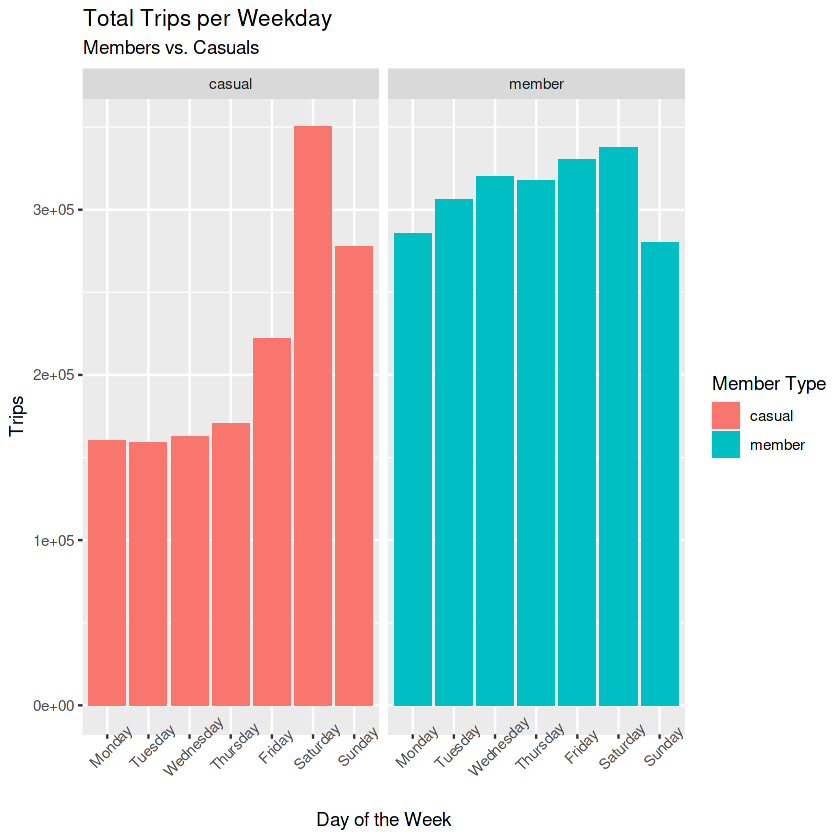

In [17]:
ggplot(data = weekly_usage)+
  geom_col(mapping = aes(x = trip_day, y = total_trips, fill = member_casual))+
  theme(axis.text.x = element_text(angle = 45))+
  labs(title = 'Total Trips per Weekday', subtitle = 'Members vs. Casuals', x = 'Day of the Week', y = 'Trips', fill = 'Member Type')+
  facet_wrap(~member_casual)

From the plot we can observe that members are more consistent with their usage. Casual riders, on the other hand, have low usage on weekdays with usage increasing as the week progresses. As expected, casual riders' trip usage is high on Friday, Saturday and Sunday, with peak achieved on Saturday.

**The consistency of members' weekly usage demonstrates that they know what to use the bikes for. Perhaps we can use this hypothesis to come with strategies to entice casual riders to opt in for a membership.**

Now, let's plot our findings on **average trip length**:

Don't know how to automatically pick scale for object of type difftime. Defaulting to continuous.



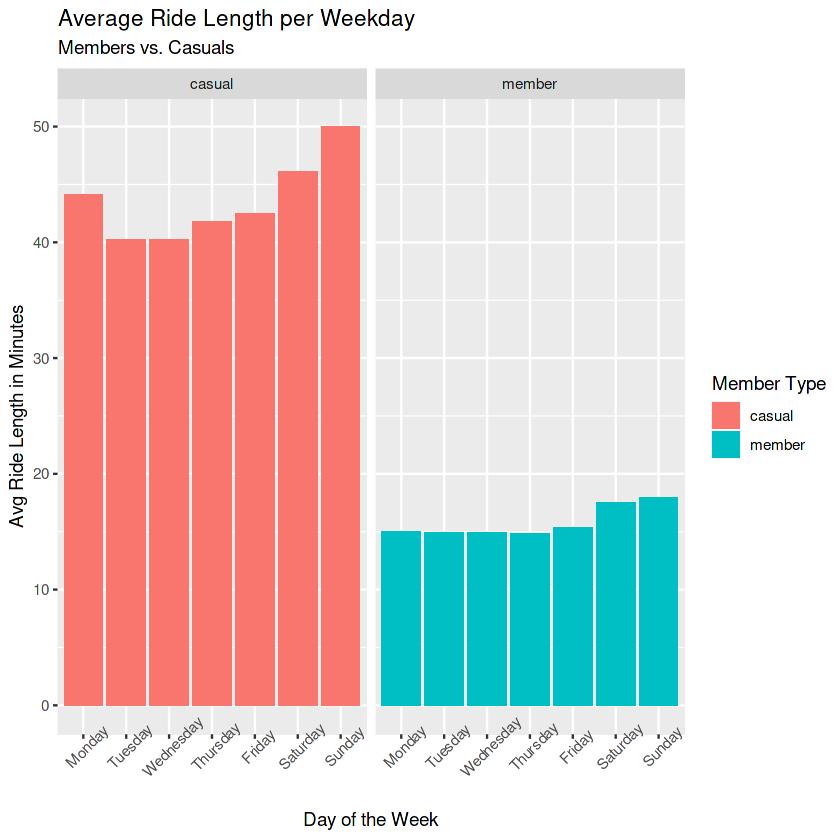

In [18]:
ggplot(data = weekly_usage)+
  geom_col(mapping = aes(x = trip_day, y = avg_trip_length, fill = member_casual))+
  theme(axis.text.x = element_text(angle = 45))+
  labs(title = 'Average Ride Length per Weekday', subtitle = 'Members vs. Casuals', x = 'Day of the Week', y = 'Avg Ride Length in Minutes', fill = 'Member Type')+
  facet_wrap(~member_casual)

This plot reveals that casual riders tend to hold on to bikes for nearly 3 times as long as members. **Casuals** tend to hold on to bikes for 40-50 minutes. Members consistently use their bikes for 15 minutes on average. This stays true with our earlier hypothesis that **members** *know what they need the bikes for*.

##### **Monthly** Comparison of Trip Frequency and Average Trip Length

Similar to the weekly analysis, we will first create a new dataset to summarise metrics on monthly basis.

In [19]:
## First, we will order the dataset by the specified vector. This is because in default R arranges by alphabet.
total_data_v5$trip_month <- ordered(total_data_v5$trip_month, levels = c("April-20", "May-20", "June-20", "July-20", "August-20", "September-20", "October-20", "November-20", "December-20", "January-21", "February-21", "March-21"))

monthly_usage <- total_data_v5 %>% 
  group_by(member_casual, trip_month) %>% 
  summarise(total_trips = n(), avg_trip_length = mean(ride_length))

head(monthly_usage)

`summarise()` has grouped output by 'member_casual'. You can override using the `.groups` argument.



member_casual,trip_month,total_trips,avg_trip_length
<chr>,<ord>,<int>,<drtn>
casual,April-20,23570,72.49064 mins
casual,May-20,86699,50.60586 mins
casual,June-20,154342,51.22886 mins
casual,July-20,268125,59.28460 mins
casual,August-20,281987,44.24402 mins
casual,September-20,214681,38.41992 mins


Let's plot our findings on **monthly trip frequency**:

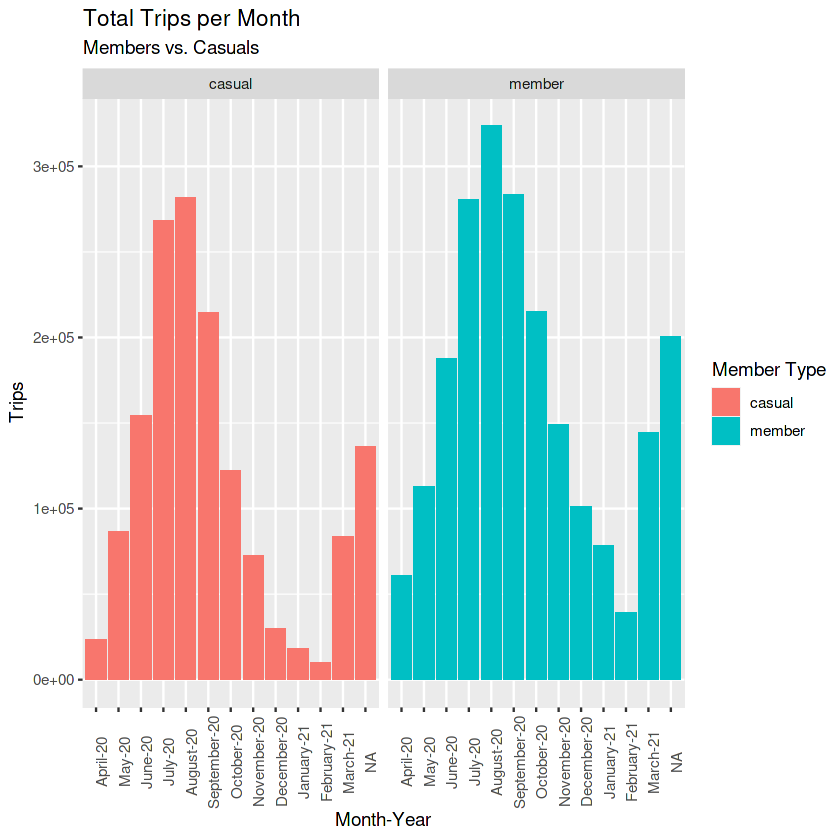

In [20]:
ggplot(data = monthly_usage)+
  geom_col(mapping = aes(x = trip_month, y = total_trips, fill = member_casual))+
  theme(axis.text.x = element_text(angle = 90))+
  labs(title = 'Total Trips per Month', subtitle = 'Members vs. Casuals', x = 'Month-Year', y = 'Trips', fill = 'Member Type')+
  facet_wrap(~member_casual)

This has revealed something quite contrary to our weekly trip usage analysis. The distribution of monthly trip usage amongst casual riders and members is very similar! Usage peaks in the summer month from July-September suggesting the our bike usage is seasonal.

To compare bike usage against Chicago's weather pattern, we browse through the weather data provided on [this Weather Spark page](https://weatherspark.com/y/14091/Average-Weather-in-Chicago-Illinois-United-States-Year-Round). From this information, let's comment on the below seasonal variables:

  1. Rain - Rain in Chicago historically has been pretty consistent throughout the year. This means, on average, it rains evenly all year round. So we can rule out rain causing dips in our usage.
  
  2. Temperature - The temperature graphs show that Chicago can get very cold during the winter months. The warmest months are June to September. From this we can infer that riders prefer to ride during the warmer months as opposed to colder months.
  
  3. Tourism - Tourist numbers are at their peak also from June to September. This also aids to our earlier hypothesis as to why ride usage peaks from July to September. More over, increased tourism from June to September also explains why casual ridership is inconsistent with membership in weekly usage which we analysed earlier.

Now let's plot our **average trip length**:

Don't know how to automatically pick scale for object of type difftime. Defaulting to continuous.



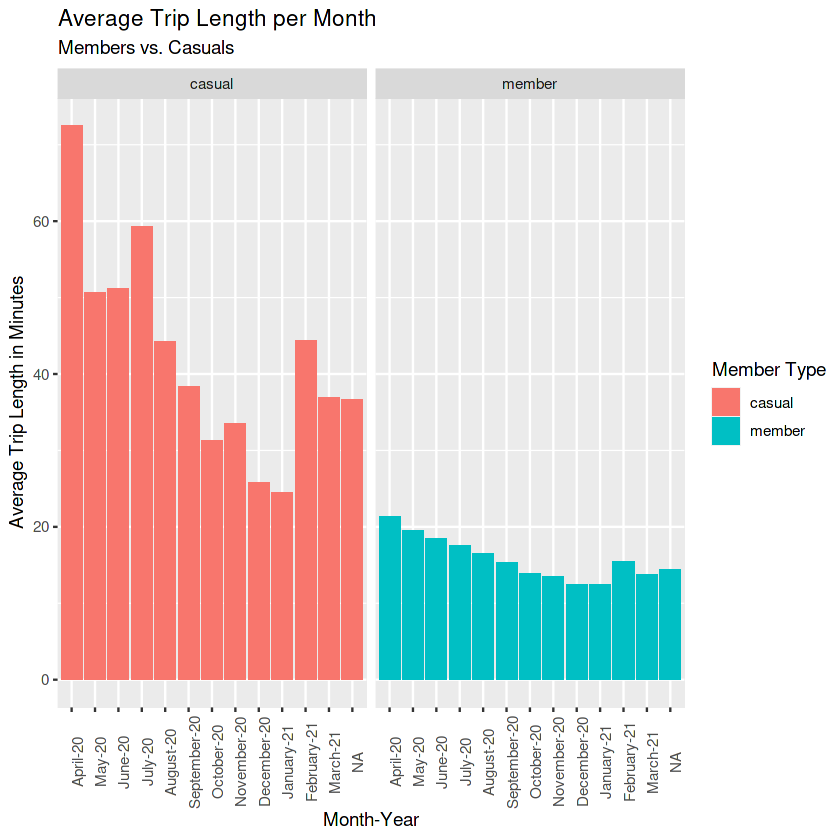

In [21]:
ggplot(data = monthly_usage)+
  geom_col(mapping = aes(x = trip_month, y = avg_trip_length, fill = member_casual))+
  theme(axis.text.x = element_text(angle = 90))+
  labs(title = 'Average Trip Length per Month', subtitle = 'Members vs. Casuals', x = 'Month-Year', y = 'Average Trip Length in Minutes', fill = 'Member Type')+
  facet_wrap(~member_casual)

Similar to monthly trip frequency, we see that trip length distribution on a *monthly basis* is also similar between members and casual riders. An interesting observation here is that average ride length distribution starts rising from February and peaks in April before declining. This is true for both members and casual riders. **So there are shorter and more frequent trips in the summer and longer less request trips around spring time from February to May, for both members and casual riders.**

## Answering the Business Questions: Why and How to get Casual Riders to buy a Cyclistic Membership

To get casual riders to buy memberships, we can offer value benefits for membership usage. Value can come from **monetary benefits** and also the **convenience benefits** of using the Cyclistic product. We saw from our quick stats that casuals tend to hold bikes for over 24 hours, which 10 times more than members. We can offer a **better fee structure for long-term bike holding**. We can also offer better convenience for members to not worry about when to return bikes. We can run this promotion through **Google, Youtube and Facebook ads**.

In terms of start locations, we can target **downtown Chicago** with our value and convenience benefits. We saw from our Tableau plots that Downtown Chicago is popular for casual riders to start their trips. In our digital campaigns we can **highlight how members save time and money** by starting their trips from the downtown area, as opposed to casual riders. We can also run **location specific mobile ads** to target users who are in the downtown area.

On the weekly and monthly analysis we noticed that tourist influx tends to effect casual ridership. Here, we can partner with popular tourism websites such as **Booking.com** or **Trip Advisor** to offer discounts to Cyclistic members.

Secondly, ridership tends to be high during the summer months. To get more users to enjoy our product, we can **run campaigns** just before summer swings in to full flow. An advantage of running ads before the peak usage period will allow us to create hype and also give users time to plan and spread the word about why they would be choosing Cyclistic for their summer activities.

Due to the seasonal nature of bike use, we can also offer users with multiple membership plans. Since usage is at its peak from July to September, we can offer a **3-month membership plan**. We can also enhance this offering towards **6-month** and **12-month plans**.

## P.S. Acknowledgement

I thank the team who curated such an expansive dataset for the purpose of this study. It has been a wonderful learning experience working on this dataset. I hope that I've broken down the steps of my analysis effectively so budding analysts have been able to understand every step of the process.

I also thank the Google Data Analytics team for curating important data analysis tools in the course. It has been a tremendous help in my data analysis journey.